---
tags: [algorithm, optimization, variational]
---

# ウォームスタート QAOA 

整数計画問題や組合せ最適化問題を解く量子アルゴリズムへの関心は、徐々に高まりつつあります。
これらを解くための手法として、断熱量子コンピューティングをトロッター化することにヒントを得た量子近似最適化アルゴリズム (QAOA) があります。
しかし、QAOA では、大きな層数 $p$ が必要となる場合には回路 depth も大きくなり、NISQ での実行が困難になります。
一方、このような問題を解くための古典的なソルバーでは、バイナリ変数を連続変数に置き換える緩和法がしばしば用いられてきました。
問題によっては、unique games conjecture のもとで、SDP 緩和と丸めが古典的に多項式時間で最良と考えられる近似比を与えることが知られています。
ここでは、QAOA の depth を浅くするための手法として、組合せ最適化問題の緩和解に対応する初期状態を用いる「ウォームスタート」について議論した [Egger et al. (2021)](https://quantum-journal.org/papers/q-2021-06-17-479/) について説明します。
Qamomile を用いた実装を行い、オリジナルの QAOA との比較も行いましょう。

In [1]:
# Install the latest Qamomile through pip! 
# !pip install qamomile

In [ ]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from scipy.optimize import minimize

import qamomile.circuit as qmc
from qamomile.circuit.algorithm.basic import superposition_vector
from qamomile.circuit.algorithm.qaoa import ising_cost, x_mixer
from qamomile.optimization.binary_model import BinaryModel
from qamomile.optimization.qaoa import QAOAConverter
from qamomile.qiskit import QiskitTranspiler

## 背景

### 問題: QAOA の限界

ゲートベースの量子コンピュータは、量子化学・機械学習・金融工学・組合せ最適化などの分野の問題を解くのに役立つと期待されています。
QAOA は、組合せ最適化問題を解くための量子アルゴリズムとして提案され、様々な応用が考えられてきました ([Farhi et al. (2014)](https://arxiv.org/abs/1411.4028) など)。
しかし、この QAOA には、次のような欠点があります。

1. 特定の問題設定では性能保証が知られているが、一般の問題に対する性能保証がない
2. [Hastings (2019)](https://arxiv.org/abs/1905.07047) では、ある種の古典局所アルゴリズムが QAOA と同等の性能になることも示している。
3. 実務面においては、NISQ には浅い depth の QAOA しか実装できない

このように、QAOA には理論・実務の両面で課題を残しており、これを現実社会の問題解決に役立てるには限界がありました。

### 先行研究

先ほどの欠点 1, 2 に関連する重要な研究として、[Bravyi et al. (2020)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.125.260505) があります。
この研究は、MaxCut のあるインスタンスにおいては、定数 depth QAOAは古典の Goemans-Williamson のランダム化丸めを上回れないことを示しました。
そこでこれを改善することを動機として、[Bravyi et al. (2020)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.125.260505) ではさらに Recursive-QAOA (RQAOA) を提案しました。
RQAOA は問題サイズを逐次的に縮小することで、特定の形の Ising ハミルトニアンでは QAOA を上回る性能を発揮すると示しました。
いわば、RQAOA はアルゴリズムの外側の構造を変化させ、変数を取り除いていく手法です。
これに対し、[Egger et al. (2021)](https://quantum-journal.org/papers/q-2021-06-17-479/) で提案された Warm-Starting QAOA (WS-QAOA) は、初期状態とミキサーを変えるという別のアプローチから QAOA を改良する手法を示したものです。

## 提案手法

### 連続緩和による初期状態作成

標準的な QUBO の目的関数は、次のように書かれるのでした。

$$
\min_{\boldsymbol{x} \in \{0, 1 \}^n} \boldsymbol{x}^\top \Sigma \boldsymbol{x} + \boldsymbol{\mu}^\top \boldsymbol{x} \tag{1}
$$

ここで $\boldsymbol{x}$ は $n$ 個のバイナリ変数を並べたベクトルであり、$\Sigma \in \mathbb{R}^{n \times n}$ は対称行列、そして $\boldsymbol{\mu} \in \mathbb{R}^n$ は実ベクトルです。
バイナリ変数においては $x_i^2 = x_i$ が成り立つことから、$\boldsymbol{\mu}$ を $\Sigma$ の対角成分に加えることもできます。
$\Sigma$ が半正定値行列の場合に、先ほどの QUBO を次のように緩和することにしましょう。

$$
\min_{\boldsymbol{x} \in [0, 1]^n} \boldsymbol{x}^\top \Sigma \boldsymbol{x}  + \boldsymbol{\mu}^\top \boldsymbol{x} \tag{2}
$$

これは凸 2 次計画問題 (QP) であり、その最適解 $\boldsymbol{c}^\ast$ は古典最適化手法により簡単に得ることができると知られています。  
もし $\Sigma$ が半正定値行列でない場合には、そのまま緩和しても凸 2 次計画になりません。
そこで、半正定値計画 (SDP) への緩和手法を用いることにしましょう。
ここで半正定値計画問題は、次のように定式化されます。

$$
\begin{align}
&\max_{Y \in \mathbb{S}^{n \times n}} \ \mathrm{tr} \ (\Sigma Y) \\
&\mathrm{s.t.} \quad \mathrm{diag} (Y) = \boldsymbol{e}, Y \succeq 0
\end{align} \tag{3}
$$

ここで $Y \in \mathbb{S}^{n \times n}$ は、$n \times n$ の対称行列、$\boldsymbol{e}$ は 1 を $n$ 個並べることでできるベクトル、そして $Y \succeq 0$ は 行列 $Y$ が半正定値行列でなければならないことを意味します。
先ほどの QP の場合と異なり、SDP では解が行列 $Y$ となることに注意が必要です。

### Continuous warm-start QAOA

元の QUBO を緩和して得られた 式 (2), (3) の解を古典的に求め、それを QAOA の初期状態に用いるというのが、 WS-QAOA です。
このページでは式 (2) の最適解 $\boldsymbol{c}^\ast$ を初期状態に埋め込む方法を示します。
SDP である (3) 式の最適解 $Y^\ast$ を利用する場合には、丸めなどにより初期ビット列や初期確率へ変換する必要があります。
式 (2) の最適解 $\boldsymbol{c}^\ast$ を埋め込む場合には、次のようにします。

$$
\vert \phi^\ast \rangle 
= \bigotimes_{i=0}^{n-1} \hat{R}_Y (\theta_i) \vert 0 \rangle \tag{4}
$$

ここで $\theta_i = 2 \mathrm{arcsin} \sqrt{c_i^\ast}$ のようにすることで、$\vert 1 \rangle$ を測定する確率が $\sin^2 (\theta_i / 2) = c_i^\ast$ に一致します。
通常の QAOA ではミキサーハミルトニアンとして、$\hat{H}_M = - \sum_i X_i$ を用いていました。
そしてそれに合わせて、初期状態もこのミキサーハミルトニアンの基底状態 $\vert + \rangle$ とします。
初期状態を式 (4) に変更するのに合わせて、これを基底状態に持つようなミキサーハミルトニアンを設計しましょう。
1 量子ビットごとのハミルトニアンを

$$
\hat{H}_{M, i}^{(\mathrm{ws})} 
= \left( \begin{array}{cc} 
2 c_i^\ast -1 & - 2 \sqrt{c_i^\ast (1 - c_i^\ast)} \\
- 2 \sqrt{c_i^\ast (1 - c_i^\ast)} & 1 - 2 c_i^\ast 
\end{array} \right)
= -\sin \theta_i \hat{X} - \cos \theta_i \hat{Z} \tag{5}
$$

とすると、これは $\hat{R}_Y (\theta_i) \vert 0 \rangle$ を基底状態に持ち、その固有値は $-1$ となります。
これを用いて、全ハミルトニアンを $\hat{H}_M^{(\mathrm{ws})} = \sum_i \hat{H}_{M, i}^{(\mathrm{ws})}$ とすることで、これは式 (4) を基底状態に持ち、その固有値は $-n$ となります。
通常の QAOA で用いられるミキサーハミルトニアンは、ブロッホ球の $x$ 軸を回転軸とする回転でしたが、WS-QAOA では $(-\sin \theta_i, 0, - \cos \theta_i)$ を回転軸とする回転であることがわかります。  
実際に QAOA で必要となる時間発展ハミルトニアンは $e^{-i \beta_k \hat{H}_M^{(\mathrm{ws})}}$ です。
これは

$$
e^{-i \beta_k \hat{H}_{M_i}^{(\mathrm{ws})}} 
= \hat{R}_Y (\theta_i) \hat{R}_Z (-2\beta_k) \hat{R}_Y (- \theta_i) \tag{6}
$$

のように、単一量子ビット回転のみで実装することができます。  
しかし、この方法では問題があります。
$c_i^\ast = 0$ の場合、$\theta_i = 0$ なので、$\vert \phi_i^\ast \rangle = \vert 0 \rangle$ であり、さらにミキサーは $\hat{H}_{M, i}^{(\mathrm{ws})} = - \hat{Z}_i$ となります。
コストハミルトニアンも $\hat{Z}_i, \hat{Z}_i \hat{Z}_j$ だけから構成されている場合、$\hat{Z} \vert 0 \rangle = \vert 0 \rangle$ であることから、その量子ビットは常に $\vert 0 \rangle$ となります。
式 (1) の最適解を $\boldsymbol{d}^\ast$ としましょう。
もし $c_i^\ast = 0$ であるのに $d_i^\ast = 1$ の場合、真の最適解に到達することはできません。
$c_i^\ast = 1$ であるのに $d_i^\ast = 0$ の場合も同様です。
このような到達可能性問題 (reachability issue) を解決するために、[Egger et al. (2021)](https://quantum-journal.org/papers/q-2021-06-17-479/) ではさらに $\epsilon \in [0, 0.5]$ のような正則化パラメータを導入しました。
そしてこれを用い

$$
\theta_i 
= \left\{ \begin{array}{ll} 
2 \mathrm{arcsin} (\sqrt{c_i^\ast}) & \mathrm{if} \ c_i^\ast \in [\epsilon, 1 -\epsilon] \\
2 \mathrm{arcsin} (\sqrt{\epsilon}) & \mathrm{if} \ c_i^\ast \leq \epsilon \\
2 \mathrm{arcsin} (\sqrt{1-\epsilon}) & \mathrm{if} \ c_i^\ast \geq 1 - \epsilon
\end{array} \right. \tag{7}
$$

のようにします。
$c_i^\ast \in [\epsilon, 1 - \epsilon]$ の場合には、そのまま $c_i^\ast$ の値を用いますが、それ以外の範囲では $\epsilon, 1-\epsilon$ のようにすることで $c_i^\ast \sim 0, 1$ となるような状況を回避します。
すなわち、限りなく $c_i^\ast \sim 0$ となるような状況でも、$\epsilon$ の確率だけ $x_i = 1$ を測定する確率を $\epsilon$ 以上に保ちます。
$\epsilon = 0.5$ の場合、全ての量子ビットについて $\theta_i = \pi / 2$ となり、$\hat{H}_{M, i}^{(\mathrm{ws})} = - X_i$ となります。
よって、これは通常の QAOA に一致します。

## Qamomile を用いた実装

それでは、これまで説明してきた WS-QAOA を、Qamomile で実装しましょう。

### 凸 2 次計画問題の設定

式 (1) の $\Sigma, \boldsymbol{\mu}$ を設定しましょう。
ただし、$\Sigma$ は正定値行列となるように値を設定します。
また $\Sigma$ は対称行列であるとします。

In [2]:
n = 6

Sigma = np.array(
    [
        [2.00, 0.40, 0.00, 0.00, 0.00, 0.00],
        [0.40, 1.80, 0.30, 0.00, 0.00, 0.00],
        [0.00, 0.30, 1.60, 0.20, 0.00, 0.00],
        [0.00, 0.00, 0.20, 1.70, 0.35, 0.00],
        [0.00, 0.00, 0.00, 0.35, 1.90, 0.25],
        [0.00, 0.00, 0.00, 0.00, 0.25, 1.50],
    ],
    dtype=float,
)

mu = np.array([-0.976, -3.226, -1.900, -2.714, -1.638, -2.790], dtype=float)

assert Sigma.shape == (n, n)
assert mu.shape == (n,)
assert np.allclose(Sigma, Sigma.T), "Sigma must be symmetric."

eigenvalues = np.linalg.eigvalsh(Sigma)
assert eigenvalues.min() >= -1e-10, "Continuous WS-QAOA in this notebook assumes Sigma is PSD."

print("eigenvalues(Sigma) =", np.round(eigenvalues, 6))

eigenvalues(Sigma) = [1.205249 1.335055 1.559749 1.79683  2.233567 2.36955 ]


### QUBO への変換

バイナリ変数においては $x_i^2 = x_i$ が成り立つので

$$
\boldsymbol{x}^\top \Sigma \boldsymbol{x} + \boldsymbol{\mu}^\top \boldsymbol{x} 
= \sum_i (\Sigma_{ii} + \mu_i) x_i + 2 \sum_{i<j} \Sigma_{ij} x_i x_j 
= \sum_{i, j} Q_{ij} x_i x_j \tag{8}
$$

のように、QUBO 行列で表すことにしましょう。
変数の数が小規模な場合、全状態を列挙することで、最適解を求めることができます。
ここでは比較のために、これも計算しています。

In [3]:
qubo = {}

for i in range(n):
    qubo[(i, i)] = float(Sigma[i, i] + mu[i])

for i in range(n):
    for j in range(i + 1, n):
        coefficient = float(2.0 * Sigma[i, j])
        if not np.isclose(coefficient, 0.0):
            qubo[(i, j)] = coefficient

print("QUBO coefficients")
for key, value in qubo.items():
    print(f"  {key}: {value:+.6f}")

all_bits = np.array(list(itertools.product([0, 1], repeat=n)), dtype=int)
exact_energies = np.einsum("bi,ij,bj->b", all_bits, Sigma, all_bits) + all_bits @ mu

qubo_energies = np.zeros(len(all_bits), dtype=float)
for (i, j), coefficient in qubo.items():
    qubo_energies += coefficient * all_bits[:, i] * all_bits[:, j]

assert np.allclose(exact_energies, qubo_energies)

exact_energy = float(exact_energies.min())
optimal_mask = np.isclose(exact_energies, exact_energy, atol=1e-10, rtol=0.0)
optimal_bits = all_bits[optimal_mask]

print()
print("Exact binary optimum (validation only)")
print("  f(x*)               =", exact_energy)
print("  number of optima    =", len(optimal_bits))
for bits in optimal_bits:
    print("  optimal bit string  =", bits.tolist())

QUBO coefficients
  (0, 0): +1.024000
  (1, 1): -1.426000
  (2, 2): -0.300000
  (3, 3): -1.014000
  (4, 4): +0.262000
  (5, 5): -1.290000
  (0, 1): +0.800000
  (1, 2): +0.600000
  (2, 3): +0.400000
  (3, 4): +0.700000
  (4, 5): +0.500000

Exact binary optimum (validation only)
  f(x*)               = -3.7300000000000004
  number of optima    = 1
  optimal bit string  = [0, 1, 0, 1, 0, 1]


### 連続緩和 QP を解く

QAOA へのウォームスタート初期状態を準備するために、緩和した問題を解きましょう。ここでは SciPy の L-BFGS-B 手法を用い、さらに $0 \leq c_i \leq 1$ の制約を課しています。

In [4]:
qp_result = minimize(
    fun=lambda c: float(c @ Sigma @ c + mu @ c),
    x0=np.full(n, 0.5, dtype=float),
    jac=lambda c: 2.0 * Sigma @ c + mu,
    bounds=[(0.0, 1.0)] * n,
    method="L-BFGS-B",
    options={"ftol": 1e-14, "gtol": 1e-10, "maxiter": 1000},
)

if not qp_result.success:
    raise RuntimeError(f"QP solver failed: {qp_result.message}")

c_star = np.clip(qp_result.x, 0.0, 1.0)
qp_energy = float(c_star @ Sigma @ c_star + mu @ c_star)

print("QP status :", qp_result.message)
print("c*        :", np.round(c_star, 6))
print("f(c*)     :", qp_energy)

QP status : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
c*        : [0.08 0.82 0.35 0.72 0.18 0.9 ]
f(c*)     : -4.07416


### 正則化パラメータの導入と初期分布の作成

$\epsilon$ を導入し、先ほど得られた $c_i^\ast$ を $\epsilon \leq c_i^\ast \leq 1 - \epsilon$ の範囲に限定しましょう。
そして、式 (7) を用い、QAOA に用いる角度分布を求めます。

In [5]:
epsilon = 0.10

if not (0.0 < epsilon <= 0.5):
    raise ValueError("epsilon must satisfy 0 < epsilon <= 0.5")

c_tilde = np.clip(c_star, epsilon, 1.0 - epsilon)
thetas = 2.0 * np.arcsin(np.sqrt(c_tilde))
theta_binding = [float(value) for value in thetas]

uniform_probabilities = np.full(len(all_bits), 1.0 / len(all_bits), dtype=float)
warm_probabilities = np.prod(
    np.where(all_bits == 1, c_tilde[None, :], 1.0 - c_tilde[None, :]),
    axis=1,
)

assert np.isclose(uniform_probabilities.sum(), 1.0)
assert np.isclose(warm_probabilities.sum(), 1.0)

standard_initial_optimum_probability = float(uniform_probabilities[optimal_mask].sum())
warm_initial_optimum_probability = float(warm_probabilities[optimal_mask].sum())
standard_initial_mean_energy = float(uniform_probabilities @ exact_energies)
warm_initial_mean_energy = float(warm_probabilities @ exact_energies)

print("epsilon   :", epsilon)
print("c_tilde   :", np.round(c_tilde, 6))
print("theta     :", np.round(thetas, 6))

initial_summary = pd.DataFrame(
    {
        "initial mean energy": [
            standard_initial_mean_energy,
            warm_initial_mean_energy,
            warm_initial_mean_energy,
        ],
        "initial mean optimality gap": [
            standard_initial_mean_energy - exact_energy,
            warm_initial_mean_energy - exact_energy,
            warm_initial_mean_energy - exact_energy,
        ],
        "initial P(optimum)": [
            standard_initial_optimum_probability,
            warm_initial_optimum_probability,
            warm_initial_optimum_probability,
        ],
    },
    index=[
        "Standard QAOA",
        "Warm initial state + X mixer",
        "Continuous WS-QAOA",
    ],
)

display(initial_summary.round(6))

epsilon   : 0.1
c_tilde   : [0.1  0.82 0.35 0.72 0.18 0.9 ]
theta     : [0.643501 2.265295 1.266104 2.026395 0.876298 2.498092]


,initial mean energy,initial mean optimality gap,initial P(optimum)
Standard QAOA,-0.62200,3.10800,0.015625
Warm initial state + X mixer,-2.50552,1.22448,0.254893
Continuous WS-QAOA,-2.50552,1.22448,0.254893


### Qamomile を用いたバイナリモデル・イジングモデルの生成

Qamomile の `BinaryModel` に先ほどの QUBO 行列を渡すことで、バイナリモデルを生成します。
これをさらに `QAOAConverter` に渡すことで、スピン変数を用いた表現であるイジングモデルを生成しましょう。

In [6]:
binary_model = BinaryModel.from_qubo(qubo)
converter = QAOAConverter(binary_model)
spin_model = converter.spin_model

assert binary_model.num_bits == n
assert spin_model.num_bits == n
assert np.allclose(
    [binary_model.calc_energy(bits.tolist()) for bits in all_bits],
    exact_energies,
)

print("Binary model vartype :", binary_model.vartype)
print("Number of qubits     :", spin_model.num_bits)
print("Ising linear terms   :", spin_model.linear)
print("Ising quadratic terms:", spin_model.quad)
print("Ising constant       :", spin_model.constant)

Binary model vartype : BINARY
Number of qubits     : 6
Ising linear terms   : {0: -0.712, 1: 0.3629999999999999, 2: -0.10000000000000009, 3: 0.23200000000000004, 4: -0.431, 5: 0.52}
Ising quadratic terms: {(0, 1): 0.2, (1, 2): 0.15, (2, 3): 0.1, (3, 4): 0.175, (4, 5): 0.125}
Ising constant       : -0.6220000000000001


### Qamomile 量子カーネルの定義

QAOA に用いる量子カーネルを定義しましょう。
ここでは

1. 標準的な QAOA (一様重ね合わせ初期化・X ミキサー)
2. 初期化のみ変更した QAOA
3. Continous WS-QAOA

の 3 つを定義します。

In [7]:
@qmc.qkernel
def standard_qaoa_sampling(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
    n: qmc.UInt,
) -> qmc.Vector[qmc.Bit]:
    q = superposition_vector(n)

    for layer in qmc.range(p):
        q = ising_cost(quad, linear, q, gammas[layer])
        q = x_mixer(q, -betas[layer])

    return qmc.measure(q)


@qmc.qkernel
def warm_initial_only_qaoa_sampling(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    thetas: qmc.Vector[qmc.Float],
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
    n: qmc.UInt,
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")

    for i in qmc.range(n):
        q[i] = qmc.ry(q[i], thetas[i])

    for layer in qmc.range(p):
        q = ising_cost(quad, linear, q, gammas[layer])
        q = x_mixer(q, -betas[layer])

    return qmc.measure(q)


@qmc.qkernel
def continuous_ws_qaoa_sampling(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    thetas: qmc.Vector[qmc.Float],
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
    n: qmc.UInt,
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")

    for i in qmc.range(n):
        q[i] = qmc.ry(q[i], thetas[i])

    for layer in qmc.range(p):
        q = ising_cost(quad, linear, q, gammas[layer])

        for i in qmc.range(n):
            q[i] = qmc.ry(q[i], -thetas[i])
            q[i] = qmc.rz(q[i], -2.0 * betas[layer])
            q[i] = qmc.ry(q[i], thetas[i])

    return qmc.measure(q)

`QiskitTranspiler` を用い、$\epsilon = 0.5 \ (\theta_i = \pi / 2)$ の場合に全ての量子回路が一致することをチェックします。

In [8]:
transpiler = QiskitTranspiler()
run_equivalence_check = True

if run_equivalence_check:
    sanity_p = 1
    sanity_gammas = [0.37]
    sanity_betas = [-0.41]
    half_thetas = [float(np.pi / 2.0)] * n

    standard_circuit = transpiler.to_circuit(
        standard_qaoa_sampling,
        bindings={
            "p": sanity_p,
            "quad": spin_model.quad,
            "linear": spin_model.linear,
            "gammas": sanity_gammas,
            "betas": sanity_betas,
            "n": n,
        },
    )

    initial_only_circuit = transpiler.to_circuit(
        warm_initial_only_qaoa_sampling,
        bindings={
            "p": sanity_p,
            "quad": spin_model.quad,
            "linear": spin_model.linear,
            "thetas": half_thetas,
            "gammas": sanity_gammas,
            "betas": sanity_betas,
            "n": n,
        },
    )

    continuous_circuit = transpiler.to_circuit(
        continuous_ws_qaoa_sampling,
        bindings={
            "p": sanity_p,
            "quad": spin_model.quad,
            "linear": spin_model.linear,
            "thetas": half_thetas,
            "gammas": sanity_gammas,
            "betas": sanity_betas,
            "n": n,
        },
    )

    standard_state = Statevector.from_instruction(
        standard_circuit.remove_final_measurements(inplace=False)
    )
    initial_only_state = Statevector.from_instruction(
        initial_only_circuit.remove_final_measurements(inplace=False)
    )
    continuous_state = Statevector.from_instruction(
        continuous_circuit.remove_final_measurements(inplace=False)
    )

    assert standard_state.equiv(initial_only_state)
    assert standard_state.equiv(continuous_state)
    print("Sanity check passed: epsilon=0.5 makes all three circuits equivalent.")

Sanity check passed: epsilon=0.5 makes all three circuits equivalent.


3 つの量子回路を、Qiskit Aer 用にトランスパイルしましょう。

In [9]:
p = 2

standard_executable = transpiler.transpile(
    standard_qaoa_sampling,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": n,
    },
    parameters=["gammas", "betas"],
)

initial_only_executable = transpiler.transpile(
    warm_initial_only_qaoa_sampling,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "thetas": theta_binding,
        "n": n,
    },
    parameters=["gammas", "betas"],
)

continuous_executable = transpiler.transpile(
    continuous_ws_qaoa_sampling,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "thetas": theta_binding,
        "n": n,
    },
    parameters=["gammas", "betas"],
)

print(f"Transpilation finished: n={n}, p={p}")

Transpilation finished: n=6, p=2


Depth や COBYLA へ渡す初期値などを設定しましょう。

In [10]:
METHOD_STANDARD = "Standard QAOA"
METHOD_INITIAL_ONLY = "Warm initial state + X mixer"
METHOD_CONTINUOUS = "Continuous WS-QAOA"

sample_shots = 512
maxiter = 100
optimizer_seed = 900
optimization_simulator_seed = 901

rng = np.random.default_rng(optimizer_seed)
shared_initial_params = np.concatenate(
    [
        rng.uniform(0.0, np.pi, p),
        rng.uniform(-np.pi, np.pi, p),
    ]
)

standard_executor = transpiler.executor(
    backend=AerSimulator(
        seed_simulator=optimization_simulator_seed,
        max_parallel_threads=1,
    )
)
initial_only_executor = transpiler.executor(
    backend=AerSimulator(
        seed_simulator=optimization_simulator_seed,
        max_parallel_threads=1,
    )
)
continuous_executor = transpiler.executor(
    backend=AerSimulator(
        seed_simulator=optimization_simulator_seed,
        max_parallel_threads=1,
    )
)

print("shared initial gammas:", np.round(shared_initial_params[:p], 6))
print("shared initial betas :", np.round(shared_initial_params[p:], 6))
print("sample_shots         :", sample_shots)
print("maxiter              :", maxiter)

shared initial gammas: [0.016788 0.13979 ]
shared initial betas : [ 2.559677 -2.120944]
sample_shots         : 512
maxiter              : 100


## 結果

3 つの手法の QAOA パラメータを個別に最適化しましょう。
`executable.sample()` でサンプリングした結果を、`converter.decode_to_binary_sampleset()` により解析しやすい形にデコードします。
そこから平均エネルギーを算出し、それを古典最適化器 COBYLA に渡します。 

In [11]:
def sampled_mean_energy(params, executable, executor, history):
    gammas = [float(value) for value in params[:p]]
    betas = [float(value) for value in params[p:]]

    result = executable.sample(
        executor,
        shots=sample_shots,
        bindings={"gammas": gammas, "betas": betas},
    ).result()

    decoded = converter.decode_to_binary_sampleset(result)
    mean_energy = decoded.energy_mean()
    history.append(mean_energy)
    return mean_energy


cost_histories = {
    METHOD_STANDARD: [],
    METHOD_INITIAL_ONLY: [],
    METHOD_CONTINUOUS: [],
}

optimization_specs = [
    (METHOD_STANDARD, standard_executable, standard_executor),
    (METHOD_INITIAL_ONLY, initial_only_executable, initial_only_executor),
    (METHOD_CONTINUOUS, continuous_executable, continuous_executor),
]

optimization_results = {}

for method_name, executable, executor in optimization_specs:
    history = cost_histories[method_name]

    result = minimize(
        lambda params, exe=executable, exr=executor, hist=history: sampled_mean_energy(
            params,
            exe,
            exr,
            hist,
        ),
        shared_initial_params.copy(),
        method="COBYLA",
        options={"maxiter": maxiter},
    )

    optimization_results[method_name] = result

    print()
    print(method_name)
    print("  message :", result.message)
    print("  nfev    :", result.nfev)
    print("  estimate:", result.fun)
    print("  gammas  :", np.round(result.x[:p], 6))
    print("  betas   :", np.round(result.x[p:], 6))


Standard QAOA
  message : Return from COBYLA because the trust region radius reaches its lower bound.
  nfev    : 37
  estimate: -2.8015195312500003
  gammas  : [0.577436 1.116855]
  betas   : [ 2.581107 -2.070045]

Warm initial state + X mixer
  message : Return from COBYLA because the trust region radius reaches its lower bound.
  nfev    : 39
  estimate: -3.3632617187500005
  gammas  : [0.984684 0.135807]
  betas   : [ 2.560119 -2.174143]

Continuous WS-QAOA
  message : Return from COBYLA because the trust region radius reaches its lower bound.
  nfev    : 39
  estimate: -3.5002812500000005
  gammas  : [ 0.966142 -0.039343]
  betas   : [ 2.71968  -2.109836]


標準的な QAOA > 初期状態のみ変化させた QAOA > continuous WS-QAOA のように、continous WS-QAOA が一番低いエネルギーに到達していることがわかります。
最適化によるエネルギーの推移を、描画してみましょう。

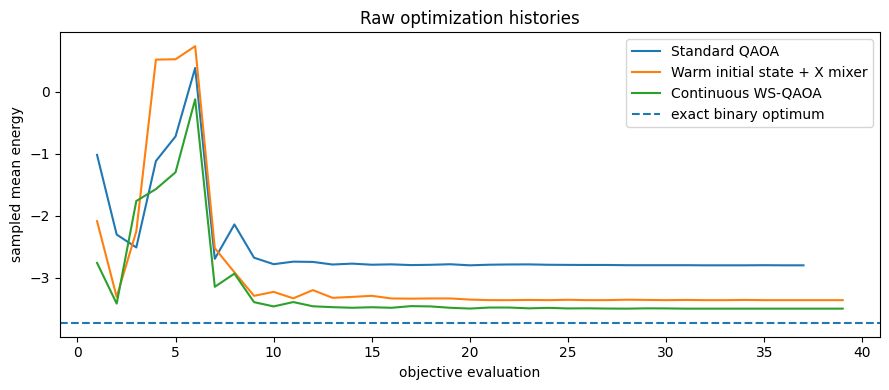

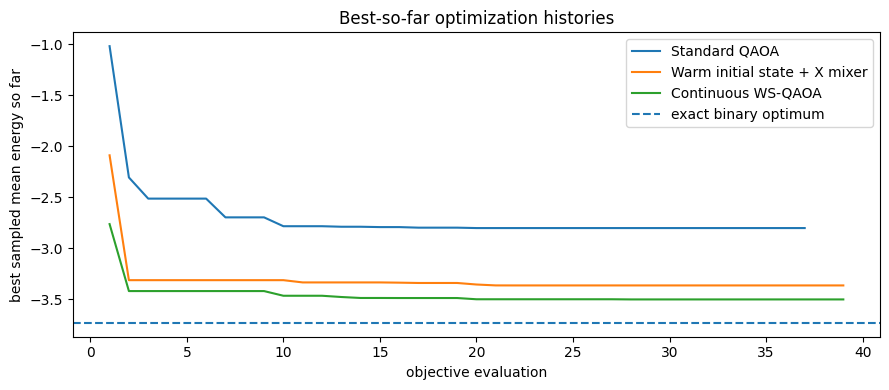

In [12]:
plt.figure(figsize=(9, 4))
for method_name, history in cost_histories.items():
    plt.plot(np.arange(1, len(history) + 1), history, label=method_name)
plt.axhline(exact_energy, linestyle="--", label="exact binary optimum")
plt.xlabel("objective evaluation")
plt.ylabel("sampled mean energy")
plt.title("Raw optimization histories")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
for method_name, history in cost_histories.items():
    best_so_far = np.minimum.accumulate(np.asarray(history, dtype=float))
    plt.plot(np.arange(1, len(history) + 1), best_so_far, label=method_name)
plt.axhline(exact_energy, linestyle="--", label="exact binary optimum")
plt.xlabel("objective evaluation")
plt.ylabel("best sampled mean energy so far")
plt.title("Best-so-far optimization histories")
plt.legend()
plt.tight_layout()
plt.show()

## まとめ

ここでは [Egger et al. (2021)](https://quantum-journal.org/papers/q-2021-06-17-479/) で提案されたウォームスタート QAOA を、Qamomile で実装する方法をご紹介しました。
以下に、このページで紹介した重要な情報をまとめます。

* ウォームスタートにより、より低いエネルギーの解を発見することに成功しました。
* 初期状態を変化させることに合わせて、ミキサーも適切なものに変更する必要があります。
* Qamomile を用いることで、QAOA の X ミキサーや、ウォームスタートのための初期化の角度などを、簡単に設定することができます。